# IY023: SimCLR Normalisation Methods — Mu Variation Training

Evaluates models trained on `data_mu_variation` using global vs joint normalisation.  
Downstream evaluation: SVM on all four variation tasks (Baseline, CV, Mu, T_ac).

In [1]:
import torch
import torch.optim as optim
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dataloaders.simclr import ssl_data_prep
from models.ssl_transformer import SSL_Transformer
%load_ext autoreload
%autoreload 2

In [2]:
# === Setup Configuration ===
# IY023 was trained on data_mu_variation
DATA_ROOT = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY020/data_mu_variation")
RESULTS_PATH = DATA_ROOT / "IY020_simulation_mu_parameters_sobol.csv"
df_params = pd.read_csv(RESULTS_PATH)
df_params = df_params[
    (df_params['success'] == True) &
    (df_params['error_message'].isna()) &
    (df_params['mean_rel_error_pct'] < 10) &
    (df_params['cv_rel_error_pct'] < 10) &
    (df_params['t_ac_rel_error_pct'] < 10)
]
TRAJ_PATH = [DATA_ROOT / df_params['trajectory_filename'].values[i] for i in range(len(df_params))]
print(f"Number of VALID trajectories: {len(TRAJ_PATH)}")

Number of VALID trajectories: 9997


In [3]:
# === Model hyperparams (must match training) ===
batch_size = 64
num_traj = 1
sample_len = None
log_scale = False
normalisation='global'

# Use global norm loader just to infer input_size
train_loader, val_loader, test_loader = ssl_data_prep(
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape)

input_size = X1_b.shape[2]
d_model = 16
nhead = 4
num_layers = 2
dropout = 0.01
use_conv1d = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])
device: cuda


In [4]:
trained_model_paths = [
'IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model.pth', # global norm
'IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model.pth' # joint norm
]

In [5]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tqdm import tqdm

from dataloaders.baseline import baseline_data_prep
from models.ssl_transformer import SSL_Transformer

# ==============================================================================
# CONFIGURATION
# ==============================================================================
DATA_BASE_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY020")

INPUT_SIZE = input_size
D_MODEL = d_model
NHEAD = nhead
NUM_LAYERS = num_layers
DROPOUT = dropout
USE_CONV1D = use_conv1d
DEVICE = device

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def load_trained_model(checkpoint_path, device):
    """Instantiates the model and loads weights."""
    print(f"Loading model from {checkpoint_path}...")
    model = SSL_Transformer(
        input_size=INPUT_SIZE,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        use_conv1d=USE_CONV1D
    )
    try:
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
    except Exception as e:
        print(f"Error loading state dict: {e}")
        raise e
    model.to(device)
    model.eval()
    return model


def extract_ssl_features(model, loader, device):
    """
    Extracts features for pairs (x1, x2) using the frozen SSL encoder.
    Feature = |Embed(x1) - Embed(x2)|
    """
    features_list = []
    labels_list = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting SSL Features", leave=False):
            X_batch, y_batch = batch
            X_batch = X_batch.to(device)

            x1 = X_batch[:, :, 0].unsqueeze(-1)
            x2 = X_batch[:, :, 1].unsqueeze(-1)

            if hasattr(model, 'encode'):
                z1 = model.encode(x1)
                z2 = model.encode(x2)
            else:
                z1 = model.backbone(x1).mean(dim=1)
                z2 = model.backbone(x2).mean(dim=1)

            feat = torch.abs(z1 - z2)
            feat_np = feat.cpu().numpy()
            if feat_np.ndim == 1:
                feat_np = feat_np.reshape(-1, 1)

            features_list.append(feat_np)
            labels_list.append(y_batch.cpu().numpy())

    return np.concatenate(features_list, axis=0), np.concatenate(labels_list, axis=0)


def train_and_evaluate_svm(train_loader, test_loader, model, device, task_name="Task"):
    """Pipeline: Extract Features -> Scale -> Train SVM -> Evaluate"""
    print(f"\n=== Processing {task_name} ===")

    print(f"   [1/4] Extracting Train Features...")
    X_train, y_train = extract_ssl_features(model, train_loader, device)

    print(f"   [2/4] Extracting Test Features...")
    X_test, y_test = extract_ssl_features(model, test_loader, device)

    print(f"   [3/4] Scaling Data...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"   [4/4] Training SVM & Evaluating...")
    clf = SVC(kernel='rbf', C=1.0)
    clf.fit(X_train_scaled, y_train.ravel())

    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"   >> {task_name} Accuracy: {acc:.2%}")
    return acc


def make_loaders(data_root: Path, results_csv: str):
    """Helper to create loaders for a specific dataset folder."""
    results_path = data_root / results_csv
    if not results_path.exists():
        print(f"Warning: Could not find {results_path}, skipping...")
        return None, None, None

    df_params = pd.read_csv(results_path)
    df_params = df_params[
        (df_params['success'] == True) &
        (df_params['error_message'].isna()) &
        (df_params['mean_rel_error_pct'] < 10) &
        (df_params['cv_rel_error_pct'] < 10) &
        (df_params['t_ac_rel_error_pct'] < 10)
    ]
    traj_paths = [data_root / fname for fname in df_params['trajectory_filename'].values]
    traj_npz_paths = [p.with_suffix('.npz') for p in traj_paths]

    train_l, val_l, test_l = baseline_data_prep(
        traj_npz_paths,
        batch_size=batch_size,
        num_groups_train=3000,
        num_groups_test=600,
        num_traj=2,
        pos_ratio=0.5,
        sample_len=500,
        stack_axis=1,
        verbose=False
    )
    return train_l, val_l, test_l


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

experiments = [
    {"name": "Baseline",      "folder": "data",              "csv": "IY020_simulation_parameters_sobol.csv"},
    {"name": "CV Variation",  "folder": "data_cv_variation", "csv": "IY020_simulation_cv_parameters_sobol.csv"},
    {"name": "Mu Variation",  "folder": "data_mu_variation", "csv": "IY020_simulation_mu_parameters_sobol.csv"},
    {"name": "T_ac Variation","folder": "data_t_ac_variation","csv": "IY020_simulation_t_ac_parameters_sobol.csv"},
]

# Collect results across all models: {model_label: {task_name: accuracy}}
all_results = {}

for MODEL_CHECKPOINT_PATH in trained_model_paths:
    model_label = Path(MODEL_CHECKPOINT_PATH).stem

    ssl_model = load_trained_model(MODEL_CHECKPOINT_PATH, DEVICE)

    results = {}
    for exp in experiments:
        data_path = DATA_BASE_DIR / exp["folder"]
        train_loader, _, test_loader = make_loaders(data_path, exp["csv"])
        if train_loader:
            acc = train_and_evaluate_svm(train_loader, test_loader, ssl_model, DEVICE, task_name=exp["name"])
            results[exp["name"]] = acc

    all_results[model_label] = results

    print("\n" + "="*30)
    print(f"RESULTS: {model_label}")
    print("="*30)
    for name, acc in results.items():
        print(f"{name:.<20} {acc:.2%}")

Loading model from IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model.pth...

=== Processing Baseline ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> Baseline Accuracy: 56.50%

=== Processing CV Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> CV Variation Accuracy: 74.83%

=== Processing Mu Variation ===
   [1/4] Extracting Train Features...


...

   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> CV Variation Accuracy: 62.83%

=== Processing Mu Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> Mu Variation Accuracy: 47.83%

=== Processing T_ac Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> T_ac Variation Accuracy: 49.83%

RESULTS: IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model
Baseline............ 50.50%
CV Variation........ 62.83%
Mu Variation........ 47.83%
T_ac Variation...... 49.83%


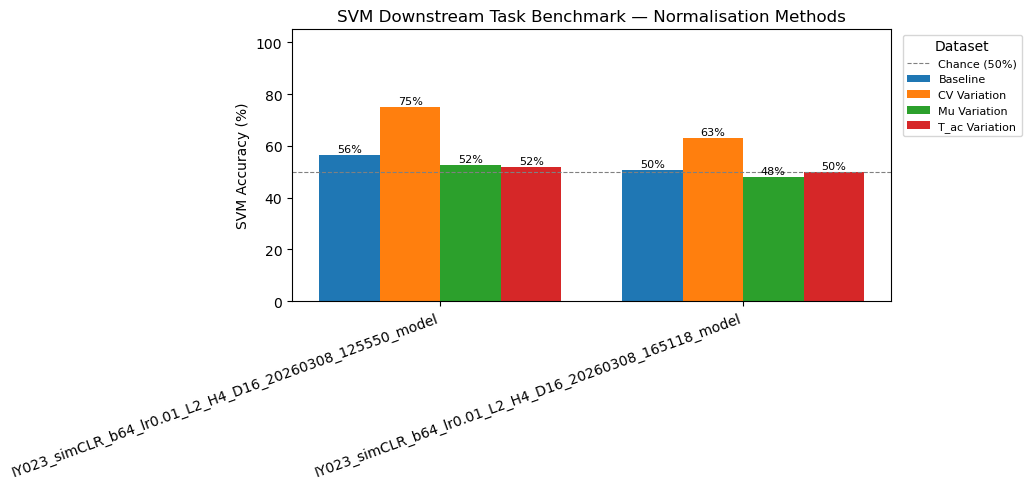

In [6]:
# ==============================================================================
# BENCHMARK PLOT: SVM accuracy across models and tasks
# x-axis = models, bars = datasets/tasks
# ==============================================================================

model_labels = list(all_results.keys())
task_names = [exp["name"] for exp in experiments]

n_models = len(model_labels)
n_tasks = len(task_names)
x = np.arange(n_models)
bar_width = 0.8 / n_tasks  # total group width = 80%

fig, ax = plt.subplots(figsize=(max(10, n_models * 2.5), 5))

for i, task in enumerate(task_names):
    accs = [all_results[m].get(task, np.nan) for m in model_labels]
    offsets = (i - (n_tasks - 1) / 2) * bar_width
    bars = ax.bar(
        x + offsets,
        [a * 100 if not np.isnan(a) else 0 for a in accs],
        width=bar_width,
        label=task,
    )

    # Annotate each bar
    for bar, acc in zip(bars, accs):
        if not np.isnan(acc):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{acc:.0%}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, label="Chance (50%)")
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=20, ha="right")
ax.set_ylabel("SVM Accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("SVM Downstream Task Benchmark — Normalisation Methods")
ax.legend(title="Dataset", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
